# Visualization

In [1]:
import os

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


def load_results(dataset_name: str) -> pd.DataFrame:
    dfs = []
    result_files = {
        "Shapley4TGNNEvent": "Shapley4TGNNEvent.csv",
        "Shapley4TGNNFeature": "Shapley4TGNNFeature.csv",
        "TGNNExplainer": "TGNNExplainer.csv",
        "TempME": "TempME.csv",
        "QIEA-TGX": "QIEA-TGX.csv",
        "Random": "Random.csv",
    }

    for explainer, filename in result_files.items():
        path = f"Results/{dataset_name}/{filename}"
        if os.path.exists(path):
            result_df = pd.read_csv(path)
            result_df["Explainer"] = explainer
            dfs.append(result_df)
        else:
            print(f"{path} does not exist.")

    if not dfs:
        return pd.DataFrame()
    return pd.concat(dfs, ignore_index=True)


datasets = ["Flights", "LinkPred", "mooc", "reddit", "UNtrade", "UNvote", "USLegis", "wikipedia", "WikipediaCAWN"]
results_dict = {d: load_results(d) for d in datasets}


Results/Flights/TempME.csv does not exist.
Results/Flights/QIEA-TGX.csv does not exist.
Results/mooc/QIEA-TGX.csv does not exist.
Results/reddit/QIEA-TGX.csv does not exist.
Results/UNtrade/QIEA-TGX.csv does not exist.
Results/UNvote/QIEA-TGX.csv does not exist.
Results/USLegis/QIEA-TGX.csv does not exist.
Results/wikipedia/Shapley4TGNNEvent.csv does not exist.
Results/wikipedia/Shapley4TGNNFeature.csv does not exist.
Results/wikipedia/QIEA-TGX.csv does not exist.
Results/WikipediaCAWN/TGNNExplainer.csv does not exist.
Results/WikipediaCAWN/TempME.csv does not exist.
Results/WikipediaCAWN/QIEA-TGX.csv does not exist.


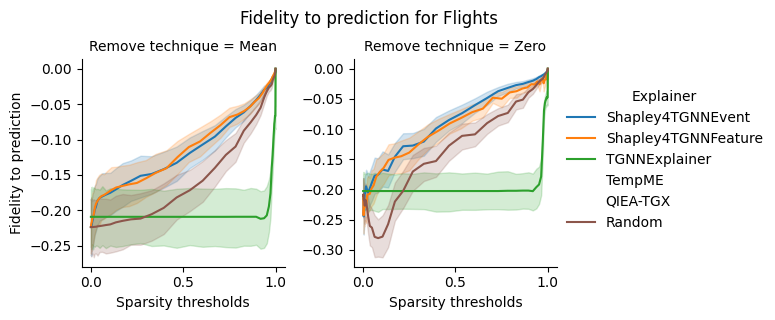

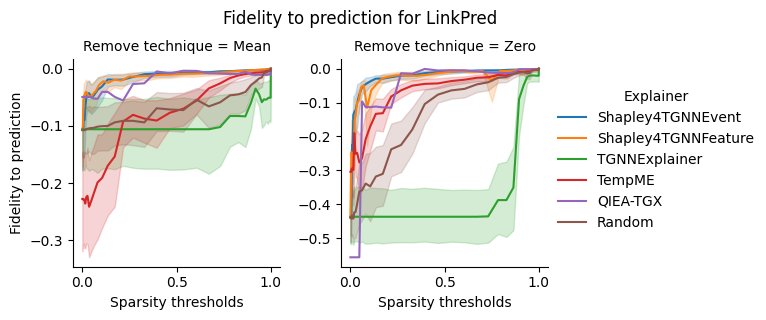

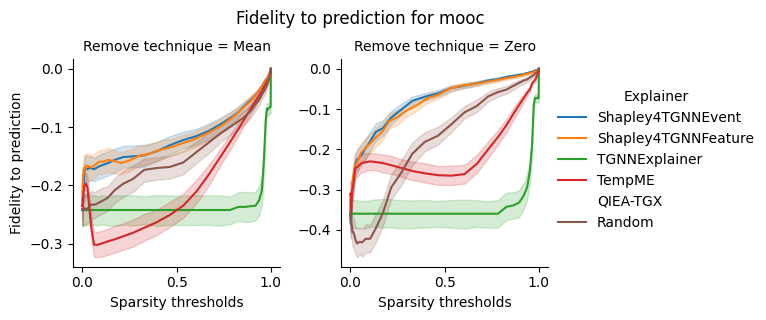

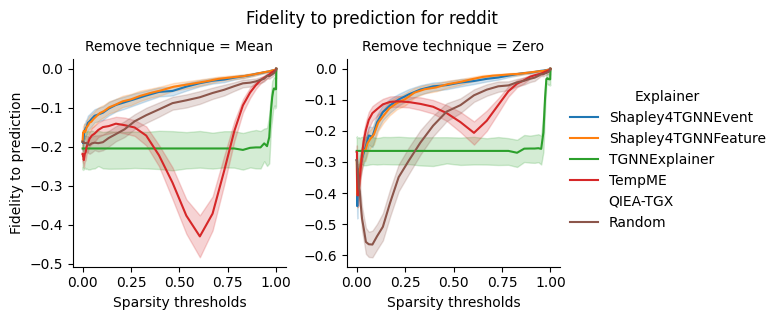

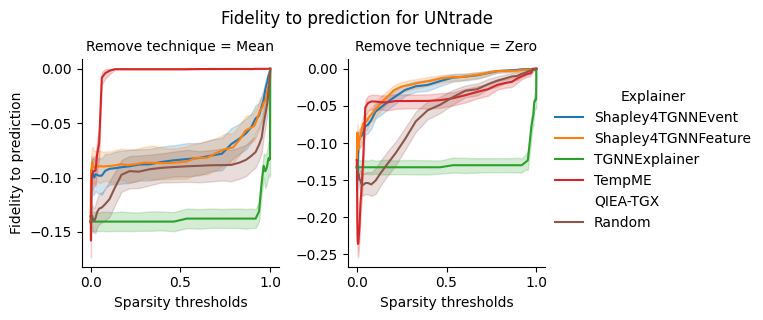

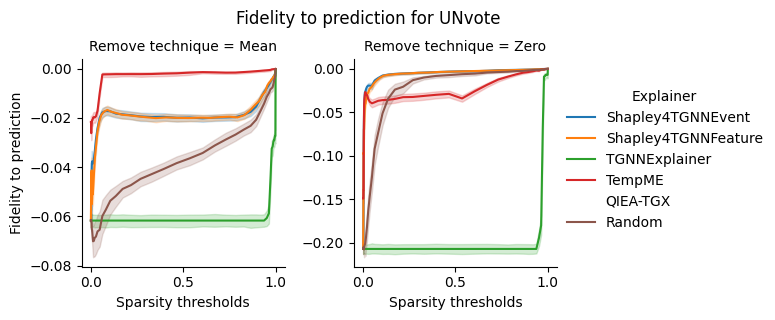

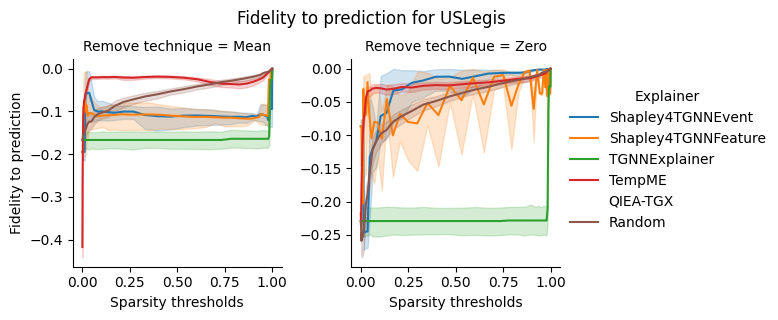

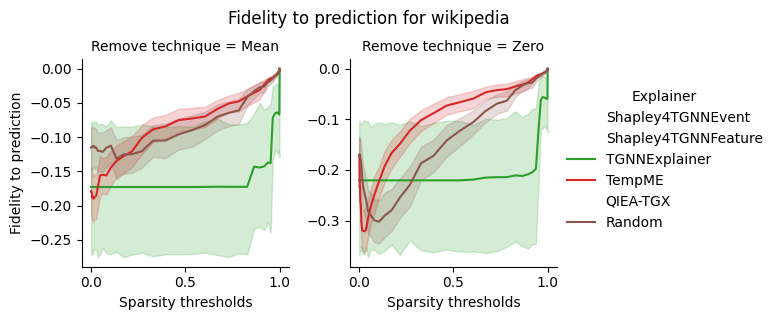

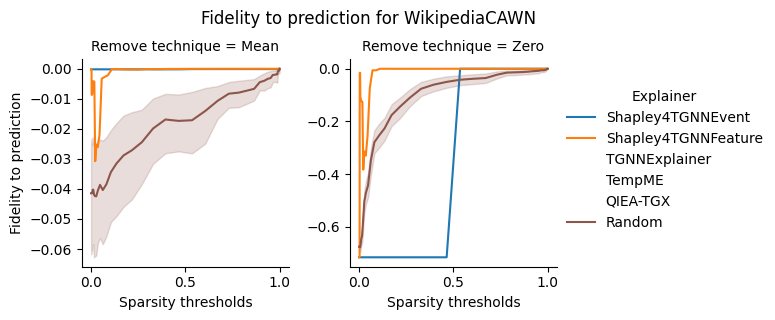

In [3]:
hue_order = [
    "Shapley4TGNNEvent", "Shapley4TGNNFeature", "TGNNExplainer",
    "TempME", "QIEA-TGX", "Random",
]

for dataset_name, df in results_dict.items():
    if df.empty:
        continue
    g = sns.FacetGrid(
        df, col="Remove technique", hue="Explainer", sharey=False,
        sharex=False, hue_order=hue_order,
    )
    g.map(sns.lineplot, "Sparsity thresholds", "Fidelity to prediction")
    g.add_legend()
    g.figure.suptitle(f"Fidelity to prediction for {dataset_name}", y=1.05)


# Statistical tests

In [22]:
from sklearn.metrics import auc
from scipy.integrate import trapezoid

# Change these two names when a different curve should be integrated.
x_column = "Sparsity thresholds"
y_column = "Fidelity to prediction"

group_columns = ["Remove technique", "Explainer", "Instance index"]

result = []

for dataset_name, df in results_dict.items():
    for identifiers, group in df.groupby(group_columns, dropna=False):
        area = trapezoid(group[y_column], group[x_column])
        technique, explainer, instance = identifiers
        result.append({
        "Dataset": dataset_name,
        "Explainer": explainer,
        "technique": technique,
        "instance": instance,
        "AUC": area,
    })

auc_df = pd.DataFrame(result, columns=["Dataset", "Explainer", "technique", "instance", "AUC"])
auc_df

,Dataset,Explainer,technique,instance,AUC
0,Flights,Random,Mean,0,-0.069536
1,Flights,Random,Mean,1,-0.439301
2,Flights,Random,Mean,2,-0.000745
3,Flights,Random,Mean,3,-0.026854
4,Flights,Random,Mean,4,-0.002607
...,...,...,...,...,...
11753,WikipediaCAWN,Random,Zero,197,-0.292806
11754,WikipediaCAWN,Random,Zero,198,-0.061029
11755,WikipediaCAWN,Random,Zero,199,-0.101213
11756,WikipediaCAWN,Shapley4TGNNEvent,Zero,105,-0.357950


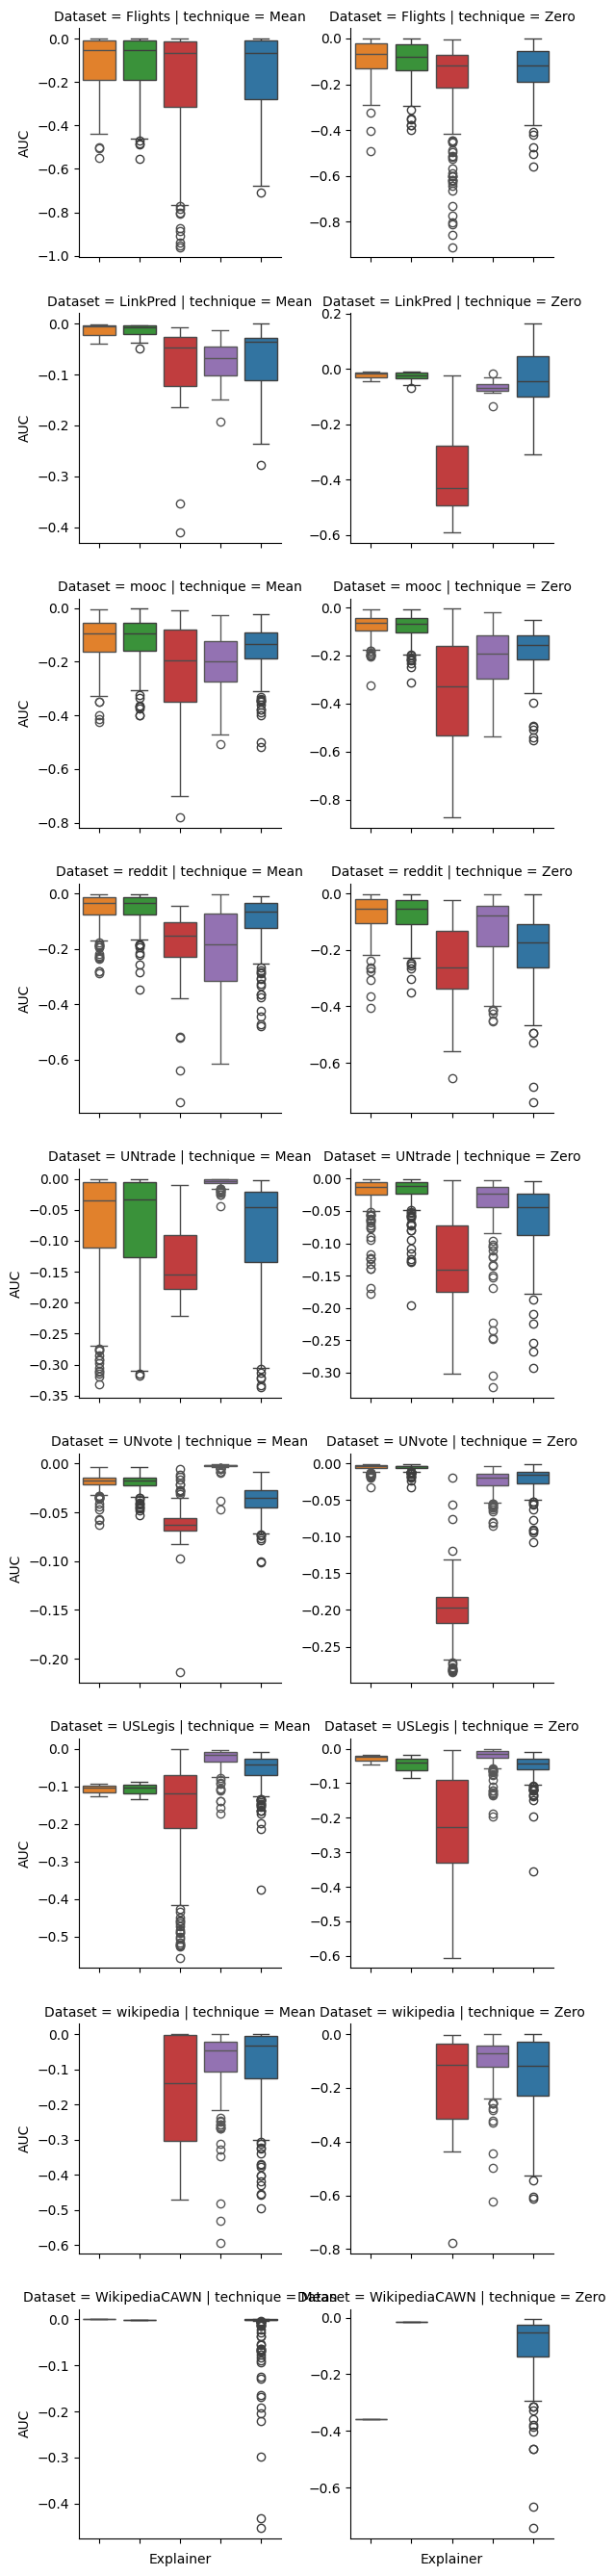

In [27]:
g = sns.FacetGrid(auc_df, row="Dataset", col="technique", hue="Explainer", sharey=False, sharex=False)
g.map(sns.boxplot, "Explainer", "AUC", order=["Shapley4TGNNEvent", "Shapley4TGNNFeature", "TGNNExplainer", "TempME", "Random"])
# Rotate x-axis labels
for ax in g.axes.flat:
    # Remove the x-axis label for the boxplot
    ax.set_xticklabels("")

In [35]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

shap_event_auc = auc_df[(auc_df["Explainer"] == "Shapley4TGNNEvent") & (auc_df["technique"] == "Zero")]
shap_feature_auc = auc_df[(auc_df["Explainer"] == "Shapley4TGNNFeature") & (auc_df["technique"] == "Zero")]
tgnn_auc = auc_df[(auc_df["Explainer"] == "TGNNExplainer") & (auc_df["technique"] == "Zero")]
tempme_auc = auc_df[(auc_df["Explainer"] == "TempME") & (auc_df["technique"] == "Zero")]
random_auc = auc_df[(auc_df["Explainer"] == "Random") & (auc_df["technique"] == "Zero")]

df_shap_event_vs_tempme = shap_event_auc.merge(tempme_auc, on=["Dataset", "technique", "instance"], suffixes=('_shap_event', '_tempme'))
df_shap_event_vs_tgnn = shap_event_auc.merge(tgnn_auc, on=["Dataset", "technique", "instance"], suffixes=('_shap_event', '_tgnn'))
df_shap_event_vs_random = shap_event_auc.merge(random_auc, on=["Dataset", "technique", "instance"], suffixes=('_shap_event', '_random'))

df_shap_feat_vs_tempme = shap_feature_auc.merge(tempme_auc, on=["Dataset", "technique", "instance"], suffixes=('_shap_feat', '_tempme'))    
df_shap_feat_vs_tgnn = shap_feature_auc.merge(tgnn_auc, on=["Dataset", "technique", "instance"], suffixes=('_shap_feat', '_tgnn'))
df_shap_feat_vs_random = shap_feature_auc.merge(random_auc, on=["Dataset", "technique", "instance"], suffixes=('_shap_feat', '_random'))

statistic1, p_value1 = wilcoxon(df_shap_event_vs_tempme['AUC_shap_event'], df_shap_event_vs_tempme['AUC_tempme'], alternative="greater")
statistic2, p_value2 = wilcoxon(df_shap_event_vs_tgnn['AUC_shap_event'], df_shap_event_vs_tgnn['AUC_tgnn'], alternative="greater")
statistic3, p_value3 = wilcoxon(df_shap_event_vs_random['AUC_shap_event'], df_shap_event_vs_random['AUC_random'], alternative="greater")
statistic4, p_value4 = wilcoxon(df_shap_feat_vs_tempme['AUC_shap_feat'], df_shap_feat_vs_tempme['AUC_tempme'], alternative="greater")
statistic5, p_value5 = wilcoxon(df_shap_feat_vs_tgnn['AUC_shap_feat'], df_shap_feat_vs_tgnn['AUC_tgnn'], alternative="greater")
statistic6, p_value6 = wilcoxon(df_shap_feat_vs_random['AUC_shap_feat'], df_shap_feat_vs_random['AUC_random'], alternative="greater")

corrected1 = multipletests([p_value1, p_value2, p_value3], method='bonferroni')[1]
corrected2 = multipletests([p_value4, p_value5, p_value6], method='bonferroni')[1]

print("Wilcoxon signed-rank test results for Shapley4TGNNEvent vs other explainers:")
print(statistic1, p_value1)
print(statistic2, p_value2)
print(statistic3, p_value3)
print("\nWilcoxon signed-rank test results for Shapley4TGNNFeature vs other explainers:")
print(statistic4, p_value4)
print(statistic5, p_value5)
print(statistic6, p_value6)

print("\nCorrected p-values for Shapley4TGNNEvent vs other explainers:")
print(corrected1)
print("\nCorrected p-values for Shapley4TGNNFeature vs other explainers:")
print(corrected2)

Wilcoxon signed-rank test results for Shapley4TGNNEvent vs other explainers:
275554.0 1.856259332561125e-58
329373.0 1.5712356628635264e-113
469582.0 3.284790592482376e-113

Wilcoxon signed-rank test results for Shapley4TGNNFeature vs other explainers:
276348.0 2.759842587070967e-59
327196.0 1.861406613806264e-110
465713.0 3.4920761899534685e-109

Corrected p-values for Shapley4TGNNEvent vs other explainers:
[5.56877800e-058 4.71370699e-113 9.85437178e-113]

Corrected p-values for Shapley4TGNNFeature vs other explainers:
[8.27952776e-059 5.58421984e-110 1.04762286e-108]


# Computation times

In [39]:
import os

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def load_results(dataset_name:str) -> pd.DataFrame:
    dfs = []
    
    if os.path.exists(f"Results/{dataset_name}/Shapley4TGNNEvent_timings.csv"):
        shap_event_df = pd.read_csv(f"Results/{dataset_name}/Shapley4TGNNEvent_timings.csv")
        shap_event_df['Explainer'] = 'Shapley4TGNNEvent'
        dfs.append(shap_event_df)
    else:
        print(f"Results/{dataset_name}/Shapley4TGNNEvent_timings.csv does not exist.")
    
    if os.path.exists(f"Results/{dataset_name}/Shapley4TGNNFeature_timings.csv"):
        shap_feature_df = pd.read_csv(f"Results/{dataset_name}/Shapley4TGNNFeature_timings.csv")
        shap_feature_df['Explainer'] = 'Shapley4TGNNFeature'
        dfs.append(shap_feature_df)
    else:
        print(f"Results/{dataset_name}/Shapley4TGNNFeature_timings.csv does not exist.")
    
    if os.path.exists(f"Results/{dataset_name}/TGNNExplainer_timings.csv"):
        tgnn_df = pd.read_csv(f"Results/{dataset_name}/TGNNExplainer_timings.csv")
        tgnn_df['Explainer'] = 'TGNNExplainer'
        dfs.append(tgnn_df)
    else:
        print(f"Results/{dataset_name}/TGNNExplainer_timings.csv does not exist.")
    
    if os.path.exists(f"Results/{dataset_name}/TempME_timings.csv"):
        tempme_df = pd.read_csv(f"Results/{dataset_name}/TempME_timings.csv")
        tempme_df['Explainer'] = 'TempME'
        dfs.append(tempme_df)
    else:
        print(f"Results/{dataset_name}/TempME_timings.csv does not exist.")
    
    if os.path.exists(f"Results/{dataset_name}/Random_timings.csv"):
        random_df = pd.read_csv(f"Results/{dataset_name}/Random_timings.csv")
        random_df['Explainer'] = 'Random'
        dfs.append(random_df)
    else:
        print(f"Results/{dataset_name}/Random_timings.csv does not exist.")
        
    results_df = pd.DataFrame(pd.concat(dfs, axis=0))
    return results_df

datasets = ["Flights", "LinkPred", "mooc", "reddit", "UNtrade", "UNvote", "USLegis", "wikipedia", "WikipediaCAWN"]
results_dict = {d: load_results(d) for d in datasets}

Results/Flights/TempME_timings.csv does not exist.
Results/wikipedia/Shapley4TGNNEvent_timings.csv does not exist.
Results/wikipedia/Shapley4TGNNFeature_timings.csv does not exist.
Results/WikipediaCAWN/TGNNExplainer_timings.csv does not exist.
Results/WikipediaCAWN/TempME_timings.csv does not exist.


In [42]:
df

,Time(ns),Time(s),Explainer,Stage,Instance Index,Dataset
0,509127566,0.509128,Shapley4TGNNEvent,Init,NaN,Flights
1,1841370759,1.841371,Shapley4TGNNEvent,Explain,0.0,Flights
2,1051152350,1.051152,Shapley4TGNNEvent,Explain,1.0,Flights
3,2103374145,2.103374,Shapley4TGNNEvent,Explain,2.0,Flights
4,2172446811,2.172447,Shapley4TGNNEvent,Explain,3.0,Flights
...,...,...,...,...,...,...
5945,4519173,0.004519,Random,Explain,195.0,WikipediaCAWN
5946,17044368,0.017044,Random,Explain,196.0,WikipediaCAWN
5947,26379576,0.026380,Random,Explain,197.0,WikipediaCAWN
5948,15951653,0.015952,Random,Explain,198.0,WikipediaCAWN


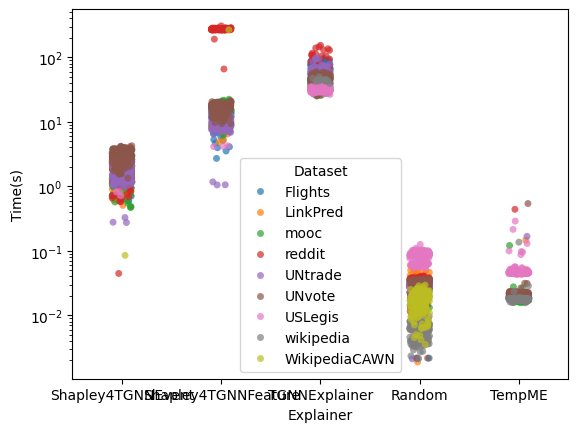

In [46]:
for dataset_name, df in results_dict.items():  
    df["Dataset"] = dataset_name

df = pd.concat(results_dict.values(), ignore_index=True)

#jitter plot
sns.stripplot(data=df[df["Stage"]=="Explain"], x="Explainer", y="Time(s)", hue="Dataset", jitter=True, alpha=0.7)
#Log scale for y-axis
plt.yscale("log")